# Sales Funnel BI Dashboard - Visualizations

## Overview

This notebook contains comprehensive business intelligence visualizations for the Pipedrive CRM sales funnel. 
It provides interactive dashboards and charts to analyze sales performance, conversion rates, and funnel metrics.

## Objectives

- Visualize sales funnel performance by stage
- Analyze monthly trends and patterns
- Calculate and display conversion rates
- Provide key performance metrics
- Generate actionable insights for sales teams

## Dashboard Components

The comprehensive BI dashboard includes 8 integrated visualizations arranged in a 3x3 grid layout:

1. **Funnel Chart - Latest Month** (Top Left): Horizontal bar chart showing deals count at each funnel stage for the most recent month, sorted by funnel step with color-coded bars and value annotations

2. **Monthly Trends - Top 5 Stages** (Top Center): Multi-line time series chart displaying the top 5 performing stages over time, with markers and trend lines to identify patterns and growth trajectories

3. **Stage Conversion Rates** (Top Right): Horizontal bar chart with color-coded conversion rates (green ≥80%, orange ≥60%, red <60%), including target lines at 80% and 60% thresholds, showing stage-by-stage conversion percentages

4. **Monthly Performance Heatmap** (Middle Left-Center): Two-column spanning heatmap showing deals count across all stages and months, color-coded for quick identification of high/low performing periods, with annotations showing exact values

5. **Key Metrics Summary** (Middle Right): Text panel displaying critical KPIs including total leads generated, total deals closed, overall conversion rate, average stage conversion, latest month statistics, and top performing stage

6. **Stage Distribution - Latest Month** (Bottom Left): Pie chart showing percentage distribution of deals across stages for the latest month, with labels and percentage annotations

7. **Cumulative Deal Flow Through Funnel** (Bottom Center): Line chart with filled area showing cumulative deal progression from first stage to last, with annotations at each stage showing cumulative totals

8. **Month-over-Month Performance** (Bottom Right): Bar chart comparing total deals across months with color coding (green for growth, red for decline, gray for first month), including percentage change annotations on each bar

## Prerequisites

- dbt models must be built and materialized
- Database connection configured
- Required Python packages installed (pandas, matplotlib, seaborn, numpy, psycopg2)


In [1]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# connection using psycopg2
conn = psycopg2.connect(
    host='localhost',
    database='postgres',
    user='admin',
    password='admin',
    port=5432
)

## 9. Dashboard Visualizations

Creating funnel analysis visualizations similar to Power BI dashboards.

In [2]:
# get final report data for visualization
funnel_data = pd.read_sql("""
    SELECT 
        month,
        kpi_name,
        funnel_step,
        deals_count
    FROM public_pipedrive_analytics.rep_sales_funnel_monthly
    ORDER BY month DESC, funnel_step
""", conn)

print("Funnel Report Data:")
print(funnel_data.head(20).to_string(index=False))

Funnel Report Data:
     month                   kpi_name  funnel_step  deals_count
2025-02-01  Implementation/Onboarding          7.0            2
2025-02-01 Follow-up/Customer Success          8.0            2
2025-02-01          Renewal/Expansion          9.0            1
2025-01-01           Needs Assessment          3.0            1
2025-01-01 Proposal/Quote Preparation          4.0            2
2025-01-01                Negotiation          5.0            5
2025-01-01                    Closing          6.0           10
2025-01-01  Implementation/Onboarding          7.0            9
2025-01-01 Follow-up/Customer Success          8.0           10
2025-01-01          Renewal/Expansion          9.0           10
2024-12-01             Qualified lead          2.0            3
2024-12-01           Needs Assessment          3.0           13
2024-12-01 Proposal/Quote Preparation          4.0           28
2024-12-01                Negotiation          5.0           28
2024-12-01          

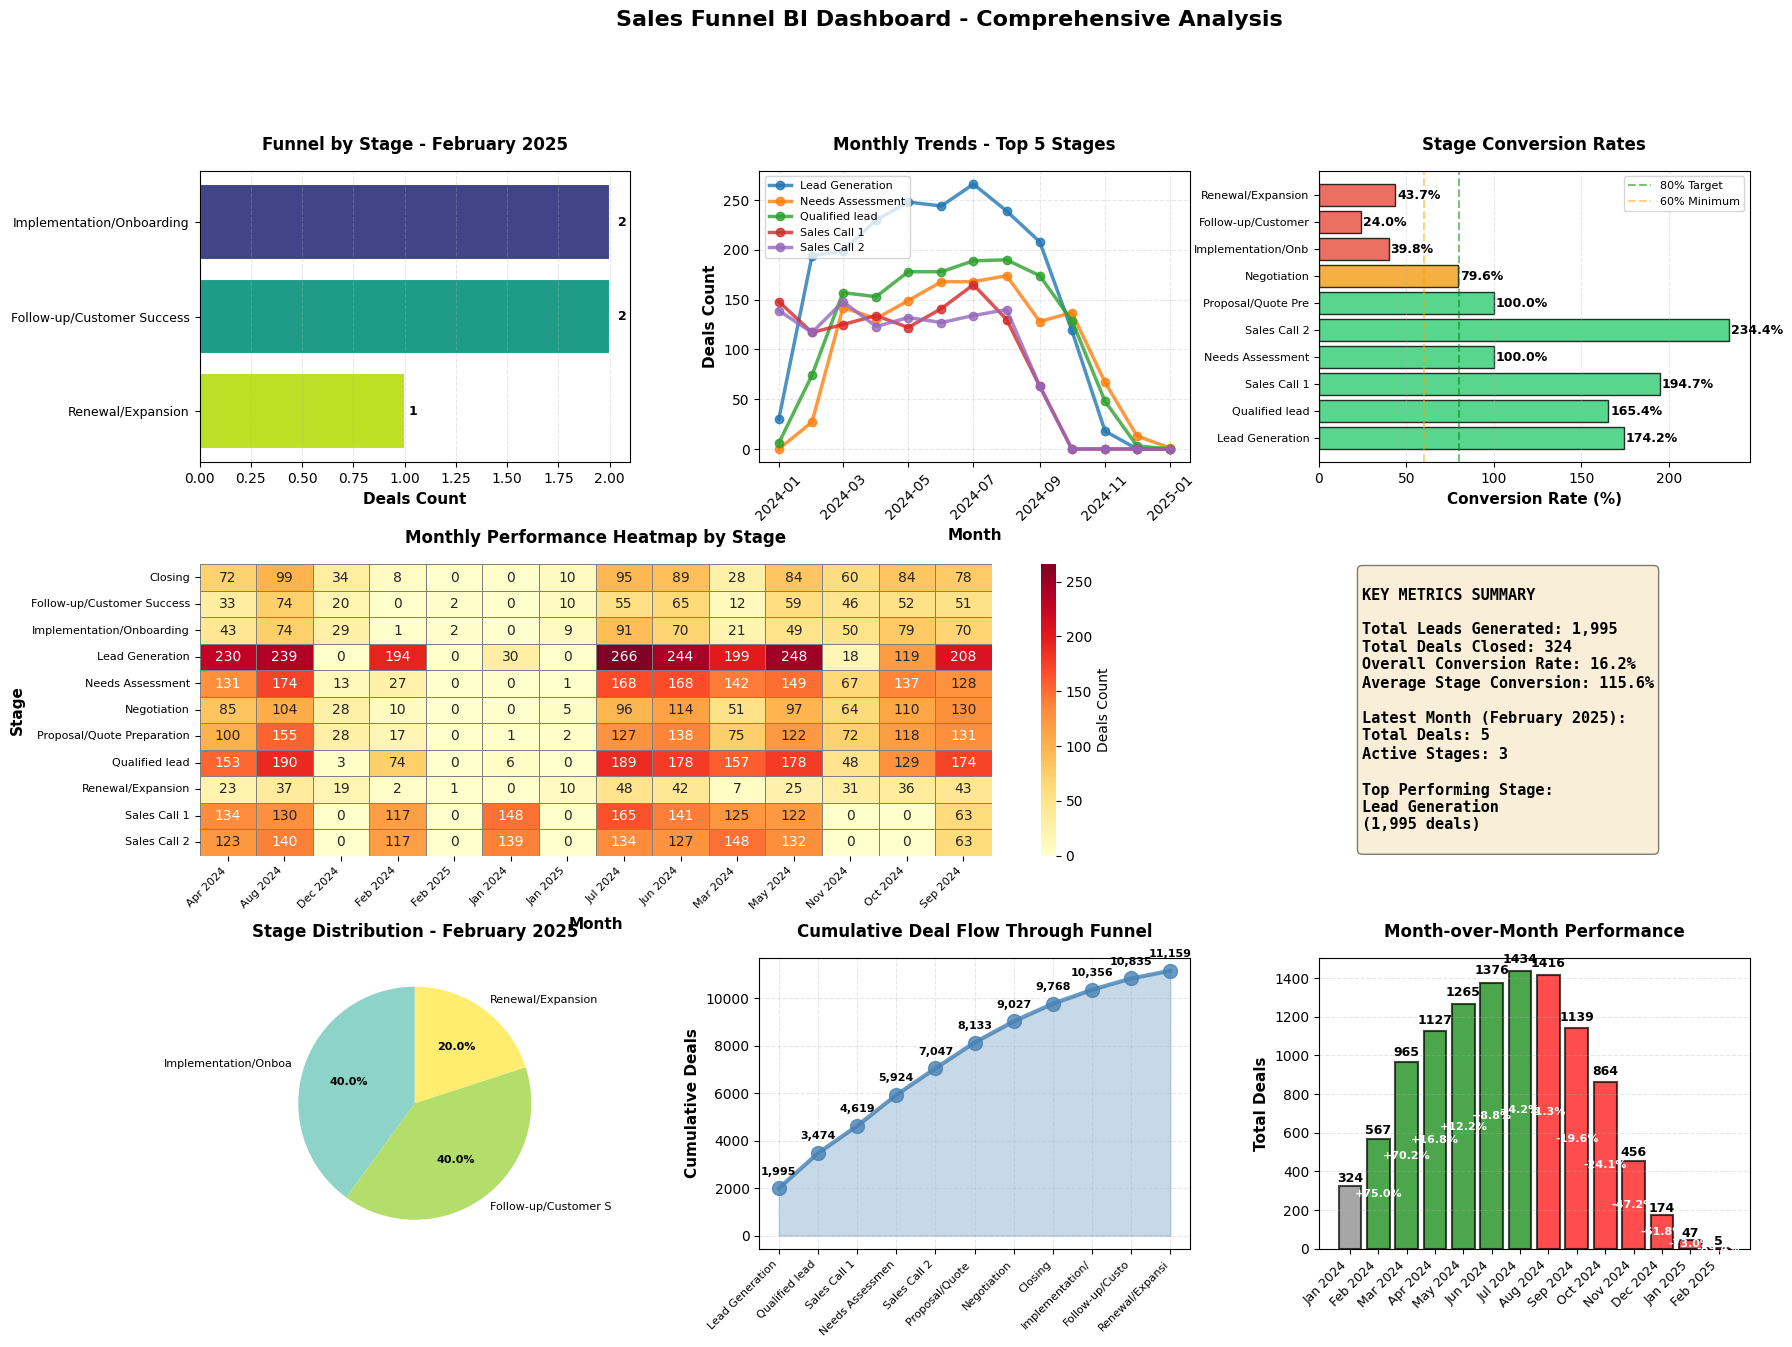


Dashboard Summary:
   • Total Leads: 1,995
   • Total Closed: 324
   • Overall Conversion: 16.24%
   • Average Stage Conversion: 115.6%


In [5]:
# Comprehensive BI Dashboard - Sales Funnel Analysis
import numpy as np

# Calculate key metrics
latest_month = funnel_data['month'].max()
latest_data = funnel_data[funnel_data['month'] == latest_month].sort_values('funnel_step')
# Group by kpi_name and funnel_step, then aggregate
all_time_totals = funnel_data.groupby(['kpi_name', 'funnel_step'])['deals_count'].sum().reset_index()
# Get first funnel_step for each kpi_name (they should be consistent)
all_time_totals = all_time_totals.groupby('kpi_name').agg({
    'deals_count': 'sum',
    'funnel_step': 'first'
}).reset_index().sort_values('funnel_step')
# Calculate conversion rates
conversion_rates = []
for i, row in all_time_totals.iterrows():
    if i == 0:
        conversion_rates.append(None)
    else:
        prev_total = all_time_totals.iloc[i-1]['deals_count']
        curr_total = row['deals_count']
        if prev_total > 0:
            conversion_rates.append((curr_total / prev_total) * 100)
        else:
            conversion_rates.append(None)

all_time_totals['conversion_rate'] = conversion_rates

# Create comprehensive dashboard
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Funnel Chart - Latest Month
ax1 = fig.add_subplot(gs[0, 0])
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(latest_data)))
bars = ax1.barh(range(len(latest_data)), latest_data['deals_count'], color=colors, edgecolor='white', linewidth=1.5)
ax1.set_yticks(range(len(latest_data)))
ax1.set_yticklabels(latest_data['kpi_name'], fontsize=9)
ax1.set_xlabel('Deals Count', fontsize=11, fontweight='bold')
ax1.set_title(f'Funnel by Stage - {latest_month.strftime("%B %Y")}', fontsize=12, fontweight='bold', pad=15)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3, linestyle='--')
for i, (bar, count) in enumerate(zip(bars, latest_data['deals_count'])):
    width = bar.get_width()
    ax1.text(width + width*0.02, bar.get_y() + bar.get_height()/2,
            f'{int(count)}', va='center', fontweight='bold', fontsize=9)

# 2. Monthly Trends - Top Stages
ax2 = fig.add_subplot(gs[0, 1])
monthly_trends = funnel_data.groupby(['month', 'kpi_name'])['deals_count'].sum().reset_index()
top_stages = monthly_trends.groupby('kpi_name')['deals_count'].sum().nlargest(5).index
trends_top = monthly_trends[monthly_trends['kpi_name'].isin(top_stages)]
pivot_trends = trends_top.pivot(index='month', columns='kpi_name', values='deals_count').fillna(0)

for col in pivot_trends.columns:
    ax2.plot(pivot_trends.index, pivot_trends[col], marker='o', linewidth=2.5, 
            label=col[:20], markersize=6, alpha=0.8)

ax2.set_xlabel('Month', fontsize=11, fontweight='bold')
ax2.set_ylabel('Deals Count', fontsize=11, fontweight='bold')
ax2.set_title('Monthly Trends - Top 5 Stages', fontsize=12, fontweight='bold', pad=15)
ax2.legend(loc='upper left', fontsize=8, ncol=1)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.tick_params(axis='x', rotation=45)

# 3. Conversion Rates Visualization
ax3 = fig.add_subplot(gs[0, 2])
conv_clean = all_time_totals[all_time_totals['conversion_rate'].notna()].copy()
conv_colors = ['#2ecc71' if x >= 80 else '#f39c12' if x >= 60 else '#e74c3c' for x in conv_clean['conversion_rate']]
bars = ax3.barh(range(len(conv_clean)), conv_clean['conversion_rate'], color=conv_colors, alpha=0.8, edgecolor='black', linewidth=1)
ax3.set_yticks(range(len(conv_clean)))
ax3.set_yticklabels(conv_clean['kpi_name'].str[:18], fontsize=8)
ax3.set_xlabel('Conversion Rate (%)', fontsize=11, fontweight='bold')
ax3.set_title('Stage Conversion Rates', fontsize=12, fontweight='bold', pad=15)
ax3.axvline(x=80, color='green', linestyle='--', alpha=0.5, label='80% Target')
ax3.axvline(x=60, color='orange', linestyle='--', alpha=0.5, label='60% Minimum')
ax3.legend(fontsize=8)
ax3.grid(axis='x', alpha=0.3, linestyle='--')
for i, (bar, rate) in enumerate(zip(bars, conv_clean['conversion_rate'])):
    width = bar.get_width()
    ax3.text(width + 1, bar.get_y() + bar.get_height()/2,
            f'{rate:.1f}%', va='center', fontweight='bold', fontsize=9)

# 4. Monthly Performance Heatmap
ax4 = fig.add_subplot(gs[1, :2])
heatmap_data = funnel_data.pivot_table(
    index='kpi_name',
    columns=funnel_data['month'].dt.strftime('%b %Y'),
    values='deals_count',
    aggfunc='sum'
).fillna(0)

sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax4,
           cbar_kws={'label': 'Deals Count'}, linewidths=0.5, linecolor='gray')
ax4.set_title('Monthly Performance Heatmap by Stage', fontsize=12, fontweight='bold', pad=15)
ax4.set_xlabel('Month', fontsize=11, fontweight='bold')
ax4.set_ylabel('Stage', fontsize=11, fontweight='bold')
plt.setp(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax4.get_yticklabels(), rotation=0, fontsize=8)

# 5. Key Metrics Summary
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
total_leads = all_time_totals[all_time_totals['funnel_step'] == 1.0]['deals_count'].values[0] if len(all_time_totals[all_time_totals['funnel_step'] == 1.0]) > 0 else 0
total_closed = all_time_totals[all_time_totals['funnel_step'] == all_time_totals['funnel_step'].max()]['deals_count'].values[0] if len(all_time_totals) > 0 else 0
overall_conversion = (total_closed / total_leads * 100) if total_leads > 0 else 0
avg_conversion = conv_clean['conversion_rate'].mean() if len(conv_clean) > 0 else 0

metrics_text = f"""
KEY METRICS SUMMARY

Total Leads Generated: {int(total_leads):,}
Total Deals Closed: {int(total_closed):,}
Overall Conversion Rate: {overall_conversion:.1f}%
Average Stage Conversion: {avg_conversion:.1f}%

Latest Month ({latest_month.strftime('%B %Y')}):
Total Deals: {int(latest_data['deals_count'].sum()):,}
Active Stages: {len(latest_data)}

Top Performing Stage:
{all_time_totals.nlargest(1, 'deals_count')['kpi_name'].values[0] if len(all_time_totals) > 0 else 'N/A'}
({int(all_time_totals.nlargest(1, 'deals_count')['deals_count'].values[0]) if len(all_time_totals) > 0 else 0:,} deals)
"""

ax5.text(0.1, 0.5, metrics_text, fontsize=11, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontweight='bold',
        family='monospace')

# 6. Stage Distribution - Latest Month
ax6 = fig.add_subplot(gs[2, 0])
pie_data = latest_data['deals_count']
pie_labels = latest_data['kpi_name'].str[:20]
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
wedges, texts, autotexts = ax6.pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
                                   colors=colors_pie, startangle=90, textprops={'fontsize': 8})
ax6.set_title(f'Stage Distribution - {latest_month.strftime("%B %Y")}', fontsize=12, fontweight='bold', pad=15)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

# 7. Cumulative Deal Flow
ax7 = fig.add_subplot(gs[2, 1])
cumulative_deals = all_time_totals['deals_count'].cumsum()
ax7.plot(range(len(all_time_totals)), cumulative_deals, marker='o', linewidth=3, 
        markersize=10, color='steelblue', alpha=0.8)
ax7.fill_between(range(len(all_time_totals)), cumulative_deals, alpha=0.3, color='steelblue')
ax7.set_xticks(range(len(all_time_totals)))
ax7.set_xticklabels(all_time_totals['kpi_name'].str[:15], rotation=45, ha='right', fontsize=8)
ax7.set_ylabel('Cumulative Deals', fontsize=11, fontweight='bold')
ax7.set_title('Cumulative Deal Flow Through Funnel', fontsize=12, fontweight='bold', pad=15)
ax7.grid(True, alpha=0.3, linestyle='--')
for i, (x, y) in enumerate(zip(range(len(all_time_totals)), cumulative_deals)):
    ax7.annotate(f'{int(y):,}', (x, y), textcoords="offset points", xytext=(0,10),
                ha='center', fontsize=8, fontweight='bold')

# 8. Month-over-Month Comparison
ax8 = fig.add_subplot(gs[2, 2])
monthly_totals = funnel_data.groupby('month')['deals_count'].sum().reset_index()
monthly_totals['month_str'] = monthly_totals['month'].dt.strftime('%b %Y')
monthly_totals['pct_change'] = monthly_totals['deals_count'].pct_change() * 100
colors_mom = ['gray' if pd.isna(x) else 'green' if x > 0 else 'red' for x in monthly_totals['pct_change']]

bars = ax8.bar(range(len(monthly_totals)), monthly_totals['deals_count'],
              color=colors_mom, alpha=0.7, edgecolor='black', linewidth=1.5)
ax8.set_xticks(range(len(monthly_totals)))
ax8.set_xticklabels(monthly_totals['month_str'], rotation=45, ha='right', fontsize=9)
ax8.set_ylabel('Total Deals', fontsize=11, fontweight='bold')
ax8.set_title('Month-over-Month Performance', fontsize=12, fontweight='bold', pad=15)
ax8.grid(axis='y', alpha=0.3, linestyle='--')

for i, (bar, count, pct) in enumerate(zip(bars, monthly_totals['deals_count'], monthly_totals['pct_change'])):
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2, height + height*0.02,
            f'{int(count)}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    if i > 0 and not pd.isna(pct):
        ax8.text(bar.get_x() + bar.get_width()/2, height/2,
                f'{pct:+.1f}%', ha='center', va='center',
                fontweight='bold', fontsize=8, color='white')

plt.suptitle('Sales Funnel BI Dashboard - Comprehensive Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.show()

print(f"\nDashboard Summary:")
print(f"   • Total Leads: {int(total_leads):,}")
print(f"   • Total Closed: {int(total_closed):,}")
print(f"   • Overall Conversion: {overall_conversion:.2f}%")
print(f"   • Average Stage Conversion: {avg_conversion:.1f}%")